### Data Load

In [31]:
import warnings
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [19]:
!pip install shap optuna

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------------ --------------- 1.3/2.2 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 5.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.6 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------  2.6/2.6 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 5.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/28.1 MB 5.6 MB/s eta 0:00:05
   -- ------------------------------------- 2.1/28.1 MB 5.6 MB/s eta 0:00:05
   ----- ---------------------------------- 3.7/28.1 MB 6.1 MB/s eta 0:00:05
   ------- -------------------------------- 5.2/28.1 MB 6.4 MB/s eta 0:00:04
   ---------- ----------------------------- 7.1/28.1 MB 6.8 MB/s eta 0:00:04
   ------------ -----------

- 0. 어떤 데이터가 들어있는지 탐색하세요.
- 0. Description Featrure 는 삭제하세요.

In [20]:
import shap
import optuna

In [11]:
del_Desc = train_df.drop('Description', axis=1, inplace=False)
del_Desc

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,PhotoAmt,AdoptionSpeed
0,Dog,2,Mixed Breed,Female,Black,Brown,Medium,Short,No,No,Healthy,0,7,2
1,Cat,24,Domestic Medium Hair,Female,Cream,No Color,Medium,Medium,Yes,Yes,Healthy,20,3,1
2,Dog,12,Spitz,Female,White,No Color,Medium,Medium,Not Sure,Not Sure,Healthy,0,4,4
3,Dog,12,Pug,Male,Black,Cream,Small,Short,Yes,Yes,Healthy,0,6,3
4,Dog,3,Mixed Breed,Male,Black,No Color,Medium,Short,Not Sure,Not Sure,Healthy,0,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10378,Dog,5,Spitz,Male,Black,Brown,Medium,Medium,No,No,Healthy,0,2,3
10379,Dog,3,Jack Russell Terrier,Female,Brown,White,Medium,Short,Yes,No,Healthy,500,1,3
10380,Cat,15,Domestic Short Hair,Male,Yellow,White,Large,Short,Yes,Yes,Healthy,0,2,1
10381,Cat,4,Domestic Short Hair,Male,Gray,No Color,Small,Medium,No,No,Healthy,0,2,4


### Data EDA

- 1. Print Data shape 
- 2. 데이터 정보 infor 를 보고 데이터를 파악하세요.

결측치 유무, 수치형/범주형 데이터 파악하고 markdown을 이용해서아래에 결과 summary 하세요.

In [12]:
print(del_Desc.shape)
del_Desc.info()
del_Desc.isna().sum()

(10383, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10383 entries, 0 to 10382
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Type           10383 non-null  object
 1   Age            10383 non-null  int64 
 2   Breed1         10383 non-null  object
 3   Gender         10383 non-null  object
 4   Color1         10383 non-null  object
 5   Color2         10383 non-null  object
 6   MaturitySize   10383 non-null  object
 7   FurLength      10383 non-null  object
 8   Vaccinated     10383 non-null  object
 9   Sterilized     10383 non-null  object
 10  Health         10383 non-null  object
 11  Fee            10383 non-null  int64 
 12  PhotoAmt       10383 non-null  int64 
 13  AdoptionSpeed  10383 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 1.1+ MB


Type             0
Age              0
Breed1           0
Gender           0
Color1           0
Color2           0
MaturitySize     0
FurLength        0
Vaccinated       0
Sterilized       0
Health           0
Fee              0
PhotoAmt         0
AdoptionSpeed    0
dtype: int64

##### 결측치 - 없음
##### 수치형 데이터 - Age, Fee, PhotoAmt, AdoptionSpeed
##### 범주형 데이터 - Breed1, Gender, Color1, Color2, MaturitySize, FurLength, Vaccinated, Sterilized, Health

- 3. 수치형 변수 | 범주형 변수를 나누세요. 

In [13]:
TARGET = "AdoptionSpeed"
feature_cols = [c for c in train_df.columns if c != TARGET]

num_cols = train_df[feature_cols].select_dtypes(include=["number"]).columns.tolist()
obj_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

print(num_cols)
print(obj_cols)

['Age', 'Fee', 'PhotoAmt']
['Type', 'Breed1', 'Gender', 'Color1', 'Color2', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'Description']


- 4. 수치형 변수를 시각화하고 각 데이터에 대해 전처리 방법을 고안해보세요. (적용할 것이 없으면 넘어감)

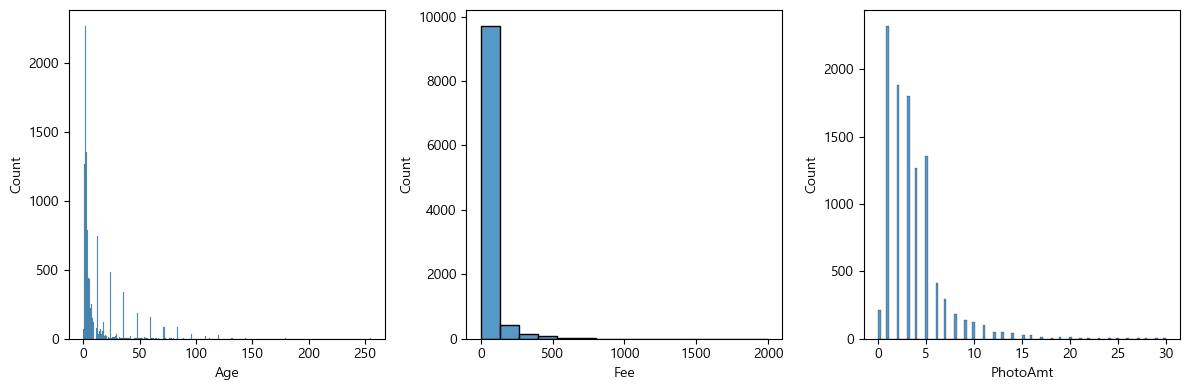

(Age
 0        67
 1      1267
 2      2274
 3      1353
 4       791
        ... 
 168       1
 180       2
 212       1
 238       1
 255       2
 Name: count, Length: 105, dtype: int64,
 Fee
 0       8609
 1         51
 5         19
 8          4
 9          3
         ... 
 700        4
 750        5
 800        2
 1000       4
 2000       1
 Name: count, Length: 63, dtype: int64,
 PhotoAmt
 0      213
 1     2324
 2     1883
 3     1804
 4     1269
 5     1356
 6      410
 7      294
 8      186
 9      141
 10     123
 11     102
 12      52
 13      49
 14      40
 15      28
 16      25
 17      13
 18       4
 19      12
 20      12
 21       4
 22       4
 23       2
 24       7
 25       4
 26       4
 27       4
 28       3
 29       2
 30       9
 Name: count, dtype: int64)

In [41]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(train_df[col], ax = ax)
plt.tight_layout()
plt.show()
vc_Age = train_df['Age'].value_counts().sort_index()
vc_Fee = train_df['Fee'].value_counts().sort_index()
vc_PhotoAmt = train_df['PhotoAmt'].value_counts().sort_index()

vc_Age, vc_Fee, vc_PhotoAmt

Age: IQR 하한=-13.00, 상한=27.00, 이상치 개수(원본 기준)=1202
Fee: IQR 하한=0.00, 상한=0.00, 이상치 개수(원본 기준)=1774
PhotoAmt: IQR 하한=-2.50, 상한=9.50, 이상치 개수(원본 기준)=503


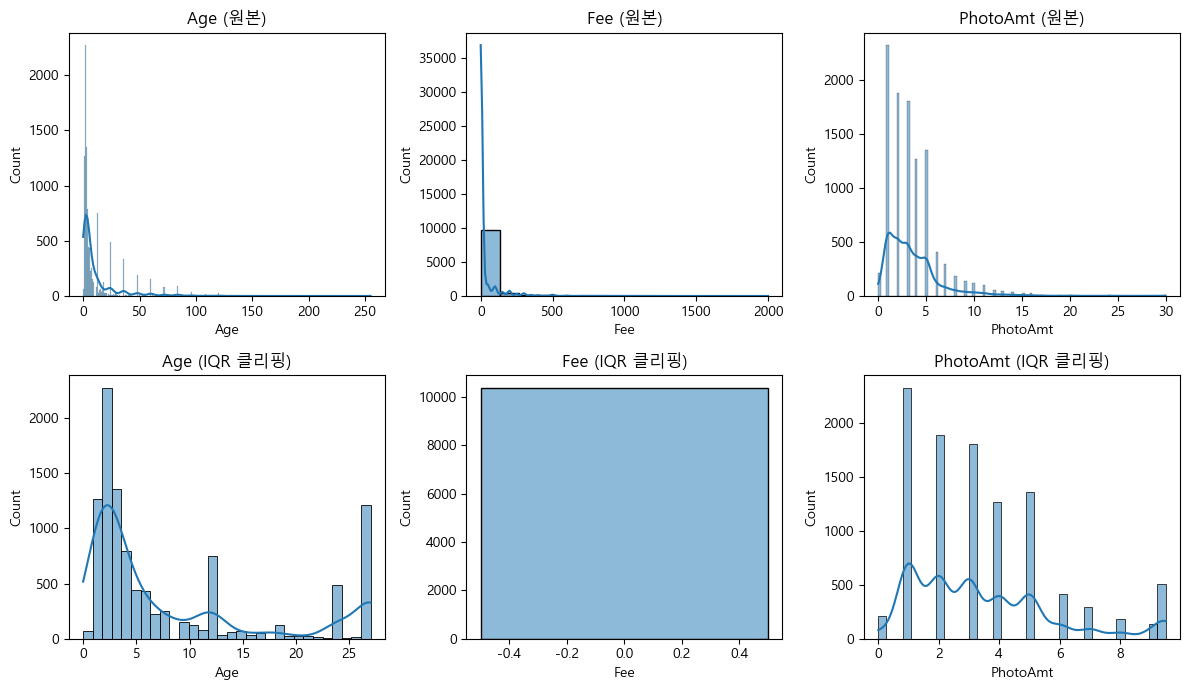

In [42]:
train_df_clipped = train_df.copy()

clip_bounds = {}

for col in num_cols:
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    clip_bounds[col] = (low, high)
    n_out = ((train_df[col] < low) | (train_df[col] > high)).sum()
    print(f"{col}: IQR 하한={low:.2f}, 상한={high:.2f}, 이상치 개수(원본 기준)={n_out}")
    train_df_clipped[col] = train_df[col].clip(lower=low, upper=high)

# 원본 vs 클리핑 후 분포 비교
fig, axes = plt.subplots(2, len(num_cols), figsize=(4 * len(num_cols), 7))
if len(num_cols) == 1:
    axes = np.array(axes).reshape(2, 1)

for j, col in enumerate(num_cols):
    sns.histplot(train_df[col], ax=axes[0, j], kde=True)
    axes[0, j].set_title(f"{col} (원본)")
    sns.histplot(train_df_clipped[col], ax=axes[1, j], kde=True)
    axes[1, j].set_title(f"{col} (IQR 클리핑)")

plt.tight_layout()
plt.show()

# 이후 단계에서 클리핑 데이터를 쓰려면 아래 주석 해제
train_df = train_df_clipped

- 5. 클래스 분포 시각화하고 데이터 분석에 있어서 우려되는 점을 기술하세요.

클래스 불균형: Target인 AdoptionSpeed 구간이 적으면 macro-F1 등에서 불리할 ㅅㅜ 있기 때문에 class_weight나 샘플 가중으로 완화

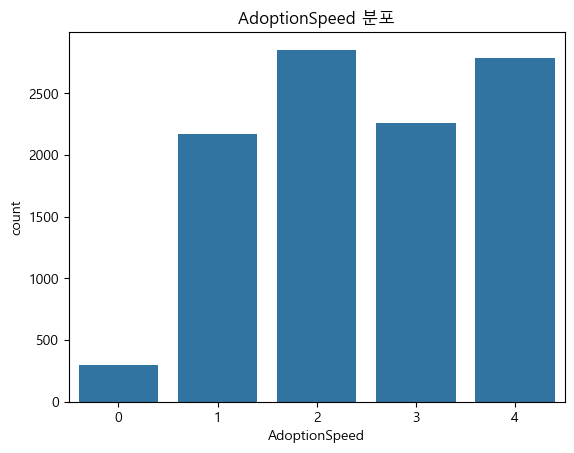

AdoptionSpeed
0     298
1    2175
2    2855
3    2264
4    2791
Name: count, dtype: int64


In [32]:
vc = train_df[TARGET].value_counts().sort_index()
sns.barplot(x=vc.index.astype(str), y=vc.values)
plt.title("AdoptionSpeed 분포")
plt.xlabel(TARGET)
plt.ylabel("count")
plt.show()
print(vc)

- 6. 범주형 변수 분포를 시각화하고 전처리 방법은 고안해보세요. (적용할 것이 없으면 넘어감)





,nunique,top,top_rate(%)
Type,2,Dog,56.59
Breed1,75,Mixed Breed,39.51
Gender,2,Female,58.06
Color1,7,Black,44.37
Color2,7,No Color,34.84
MaturitySize,3,Medium,68.89
FurLength,3,Short,54.33
Vaccinated,3,Yes,43.59
Sterilized,3,No,64.90
Health,3,Healthy,96.79


IndexError: index 8 is out of bounds for axis 0 with size 8

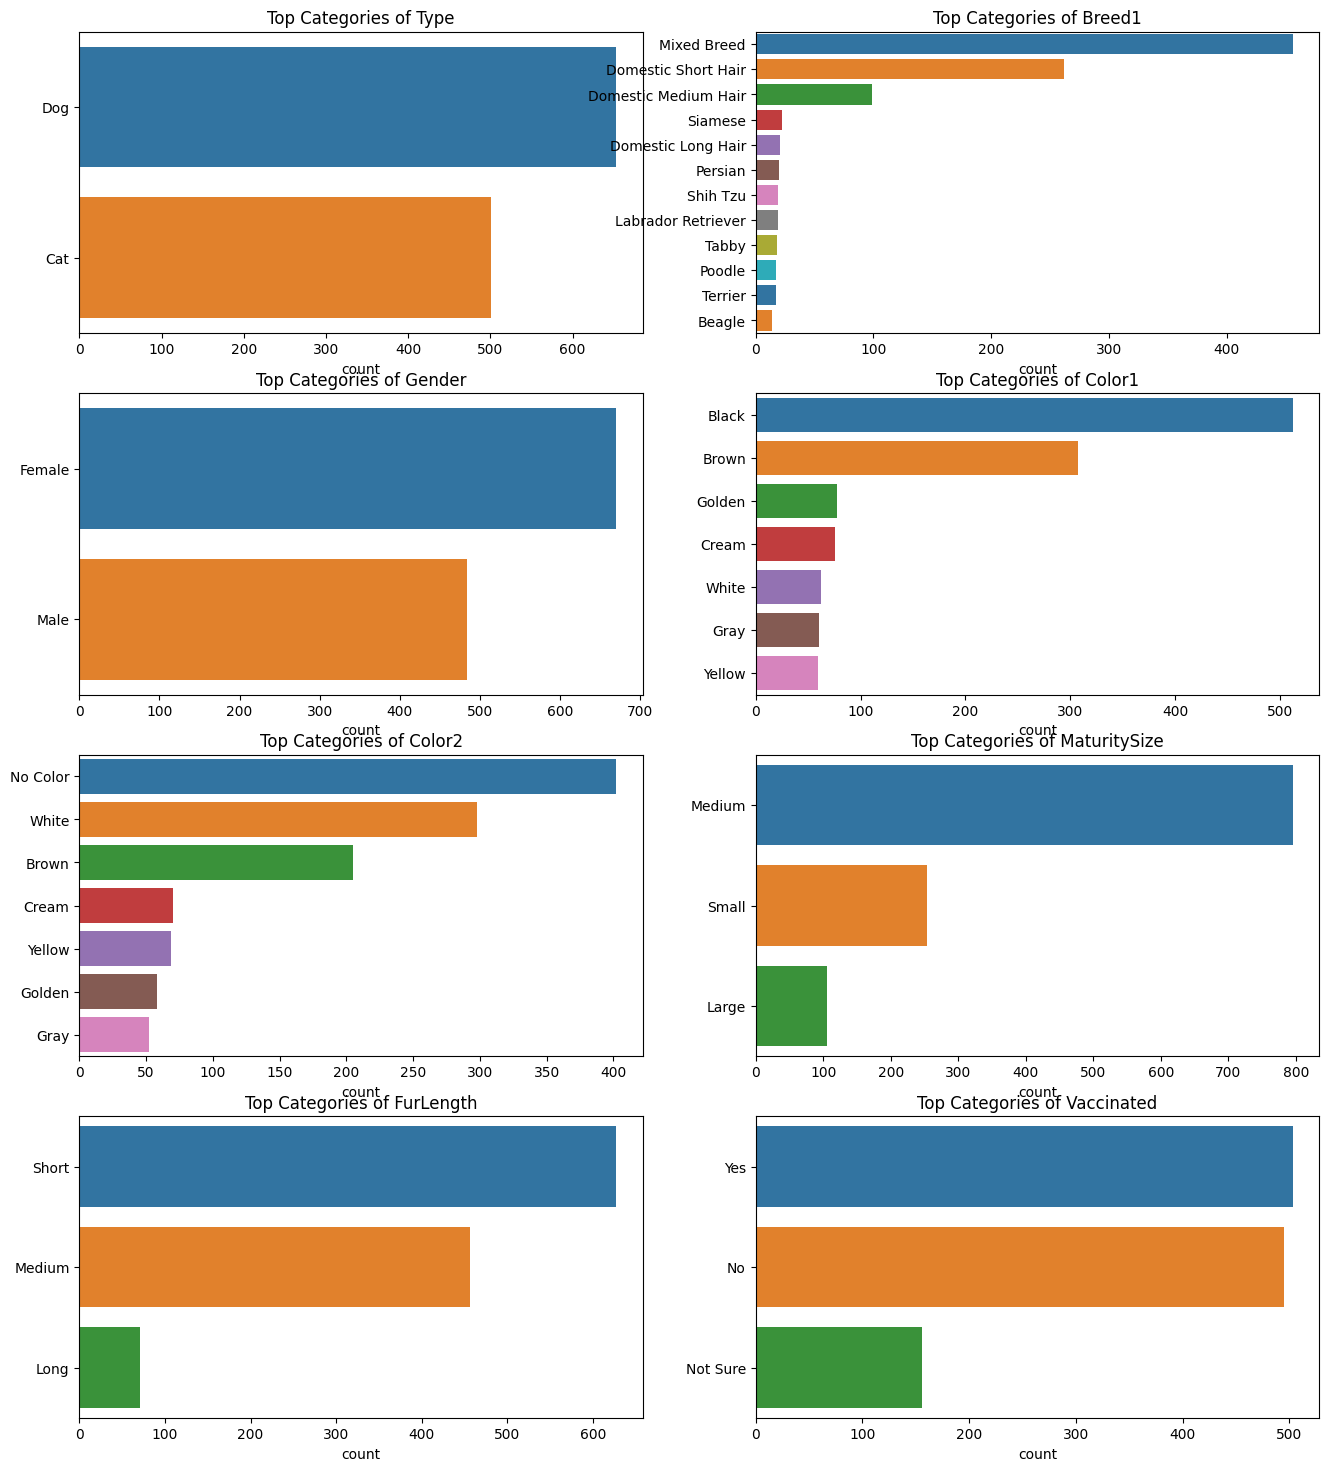

In [18]:
categorical_cols = test_df.select_dtypes(include="object").columns.tolist()
cat_summary = pd.DataFrame({
    "nunique": test_df[categorical_cols].nunique(dropna=False),
    "top": [test_df[c].fillna("Missing").mode().iloc[0] for c in categorical_cols],
    "top_rate(%)": [(test_df[c].fillna("Missing").value_counts(normalize=True).iloc[0] * 100).round(2) for c in categorical_cols],
}, index=categorical_cols)
display(cat_summary)

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()
for i, col in enumerate(categorical_cols):
    order = test_df[col].fillna("Missing").value_counts().index[:12]
    sns.countplot(data=test_df.fillna("Missing"), y=col, order=order, ax=axes[i], palette="tab10")
    axes[i].set_title(f"Top Categories of {col}")
    axes[i].set_ylabel("")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


- 7. 범주형 변수처리에 있어 Label encoding, onehot encoding 방식이 있다. 아래 내용을 고민해보세요.

    - Label encoding을 적용할 경우 어울리는 모델은?
    - Label encoding을 적용할 경우 우려되는 점은?
    - Onehot encoding을 해야되는 모델은?
    - Breed1 는 어떻게 처리하면 좋을지 고민하세요.


- 8. 위 인코딩 전략을 적용하여 실제로 인코딩을 진행하세요.
--------------------------------
- 8. Apply the encoding strategy above and actually perform the encoding.

### Feature Selection

- 9. Correlation 분석을 실시하고 feature selection 진행하세요.
- 10. Mutual Information 이 무엇인지 파악하세요. Correlation과 차이점을 파악하세요.
- 11. 9번에 이어서 Mutual Information 기반의 feature selection 진행하세요. (시각화도 하세요.)
-----------------------------------
- 9. Conduct correlation analysis and perform feature selection.
- 10. Understand what Mutual Information is and identify the differences between Mutual Information and Correlation.
- 11. Following Question 9, perform feature selection based on Mutual Information. Also visualize the results.

### Modeling

- 12. 위 학습 전략을 적용하여 전체 데이터 처리 파이프라인 만들고 데이터 정제하기



In [ ]:


# -----------------------------
# 데이터 분리
# -----------------------------

X = del_Desc.drop(columns=[TARGET])
y = del_Desc[TARGET]


# -----------------------------
# 컬럼 타입 분리
# -----------------------------

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()


# -----------------------------
# 수치형 데이터 파이프라인
# -----------------------------

numeric_pipe = Pipeline([
    ("scaler", StandardScaler())
])


# -----------------------------
# 범주형 데이터 파이프라인
# -----------------------------

categorical_pipe = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    ))
])


# -----------------------------
# 전체 전처리 파이프라인
# -----------------------------

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])


# -----------------------------
# 모델 + 전처리 통합 파이프라인
# -----------------------------

def make_pipeline(estimator):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("clf", estimator)
    ])




- 13. 학습을 위해 Train test split 을 이용해 데이터 8:2로 나누기

In [ ]:
# =========================================================
# 13. Train Test Split (8:2)
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

- 14. 적절한 모델 3가지 이상을 설정하고 학습하기 (모델 선택 이유는?)
--------------------------------
- 14. Select and train at least three appropriate models. Explain why you selected those models.

In [ ]:
# =========================================================
# 14. 모델 3가지 이상 설정 및 학습
# =========================================================

models = {

    "LogisticRegression": make_pipeline(
        LogisticRegression(
            max_iter=300,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    ),

    "RandomForest": make_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),

    "HistGradientBoosting": make_pipeline(
        HistGradientBoostingClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
}


# -----------------------------
# 모델 학습 및 예측
# -----------------------------

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")

    print("Accuracy:",
          accuracy_score(y_test, y_pred))

    print("Macro F1:",
          f1_score(y_test, y_pred, average="macro"))

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))



| 모델                   | 선택 이유                   |
| -------------------- | ----------------------- |
| Logistic Regression  | 선형 기반 베이스라인 모델로 사용      |
| Random Forest        | 비선형 관계와 변수 상호작용 처리에 강함  |
| HistGradientBoosting | 대용량 데이터와 복잡한 패턴 학습에 효율적 |


### Evaluation

- 15. 모델 평가 메트릭을 정하고 평가하기, 평가결과 분석하기 (시각화 필수)


In [ ]:

# =========================================================
# 15. 모델 평가 및 시각화
# =========================================================

# -----------------------------
# Train / Test 데이터 분포 시각화
# -----------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

y_train.value_counts().sort_index().plot(
    kind="bar",
    ax=ax[0],
    color="tab:blue"
)

ax[0].set_title("Train AdoptionSpeed Distribution")
ax[0].set_xlabel("AdoptionSpeed")
ax[0].set_ylabel("Count")


y_test.value_counts().sort_index().plot(
    kind="bar",
    ax=ax[1],
    color="tab:orange"
)

ax[1].set_title("Test AdoptionSpeed Distribution")
ax[1].set_xlabel("AdoptionSpeed")

plt.tight_layout()
plt.show()


# -----------------------------
# Confusion Matrix 시각화
# -----------------------------

fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=sorted(y.unique())
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(y.unique())
    )

    disp.plot(ax=ax, colorbar=False)

    ax.set_title(name)

plt.tight_layout()
plt.show()



- 16. Class weight / Optuna 적용해서 최적화하기


In [ ]:


def objective(trial):

    params = {

        "n_estimators":
            trial.suggest_int("n_estimators", 100, 400),

        "max_depth":
            trial.suggest_int("max_depth", 5, 30),

        "min_samples_split":
            trial.suggest_int("min_samples_split", 2, 10),

        "min_samples_leaf":
            trial.suggest_int("min_samples_leaf", 1, 5),

        "max_features":
            trial.suggest_categorical(
                "max_features",
                ["sqrt", "log2", None]
            )
    }

    clf = Pipeline([
        ("preprocessor", preprocessor),

        ("clf", RandomForestClassifier(
            **params,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    score = cross_val_score(
        clf,
        X_train,
        y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score


# -----------------------------
# Optuna 최적화 실행
# -----------------------------

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=20)


# -----------------------------
# 최적 파라미터 출력
# -----------------------------

best_params = study.best_params

print("Best Optuna params:")
print(best_params)


# -----------------------------
# 최적 모델 학습
# -----------------------------

best_pipeline = make_pipeline(

    RandomForestClassifier(
        **best_params,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)


# -----------------------------
# 최적화 모델 평가
# -----------------------------

print("\n===== Optuna Optimized RandomForest =====")

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Macro F1:",
      f1_score(y_test, y_pred, average="macro"))

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))



### Interpretation with SHAP

- 17. shap을 이용해 결과 분석하기
    - 입양 속도에 영향을 미치는 중요한 인자는?
    - 해당인자가 어떤 값을 가질 때 입양속도가 빨라지는가?
    - 통제 가능한 변수는 무엇이고 어떻게 활용 하면 좋은가?
--------------------------------
- 17. Analyze the results using SHAP.
    - What are the important factors that affect adoption speed?
    - When those factors have certain values, does the adoption speed become faster?
    - What are the controllable variables, and how can they be effectively utilized?

In [ ]:

# =========================================================
# 17. SHAP을 이용한 결과 분석
# =========================================================

try:

    # -----------------------------
    # 전처리 데이터 변환
    # -----------------------------

    X_test_transformed = (
        best_pipeline
        .named_steps["preprocessor"]
        .transform(X_test)
    )

    feature_names = (
        best_pipeline
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )


    # -----------------------------
    # SHAP Explainer 생성
    # -----------------------------

    explainer = shap.TreeExplainer(
        best_pipeline.named_steps["clf"]
    )

    shap_values = explainer.shap_values(
        X_test_transformed
    )


    # -----------------------------
    # SHAP Summary Plot
    # -----------------------------

    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=feature_names,
        show=False
    )

    plt.tight_layout()
    plt.show()


    # -----------------------------
    # 중요 변수 추출
    # -----------------------------

    if isinstance(shap_values, list):

        mean_abs = np.mean([
            np.abs(s).mean(axis=0)
            for s in shap_values
        ], axis=0)

    else:

        mean_abs = np.abs(shap_values).mean(axis=0)


    importance = pd.Series(
        mean_abs,
        index=feature_names
    ).sort_values(ascending=False).head(20)


    print("\nTop SHAP Features")
    print(importance)


except Exception as e:

    print("SHAP analysis could not be completed:")
    print(e)